In [ ]:
!pip uninstall torch -y
!pip install torch --no-cache-dir

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 206.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.7 MB/s et

In [1]:
import requests #For API Data Extraction
import pandas as pd
import numpy as np
import xgboost as xgb
import tensorflow as tf
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Packages for Model Building
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import gym #For RL Agent
import random
import math

In [ ]:
import requests
import time
from requests.auth import HTTPBasicAuth

In [ ]:
!pip install geopy

In [ ]:
from geopy.distance import geodesic

In [ ]:
from google.colab import files
airports=files.upload() #Importing Airline Dataset to match Nearest Airport as Destination for each flight

Saving airport-codes.csv to airport-codes.csv


In [ ]:
filename = list(airports.keys())[0]
airports_df = pd.read_csv(filename)

In [ ]:
airports_df=airports_df.drop(columns=['ident','type','elevation_ft','continent','iso_country','iso_region','municipality','iata_code','gps_code','local_code'])

In [ ]:
airports_df.dropna(subset=['icao_code'], inplace=True)
airports_df= airports_df[airports_df['icao_code'].str.strip() != '']

In [ ]:
airports_df[['latitude', 'longitude']] = airports_df['coordinates'].str.split(',', expand=True)
airports_df['latitude'] = airports_df['latitude'].astype(float)
airports_df['longitude'] = airports_df['longitude'].astype(float)
airports_df = airports_df.drop(columns=['coordinates'])

In [ ]:
airports_df.info()

In [ ]:
def get_current_flight_data(limit=500):
    url = "https://opensky-network.org/api/states/all"
    response = requests.get(url).json()

    flights = []
    for flight in response.get("states", [])[:limit]:
        flights.append({
            "icao24": flight[0],
            "callsign": flight[1],
            "longitude": flight[5],
            "latitude": flight[6],
            "altitude": flight[7],
            "velocity": flight[9]
        })

    return pd.DataFrame(flights)
#Creating Flight Path Details from OpenSky API

In [ ]:
current_df=get_current_flight_data()

In [ ]:
print(current_df.head())

   icao24  callsign  longitude  latitude  altitude  velocity
0  a21b74  TWY235     139.9201   37.0281   7025.64    235.81
1  4b1818  SWR2121     -4.1843   37.1044   5737.86    237.47
2  80162d  AXB298      56.4500   23.6764   8839.20    238.86
3  88044f  AIQ647     100.4263   13.5791   4259.58    183.64
4  88044e              10.6041   13.9167       NaN      1.29


In [ ]:
#Fetching Weather Data for Flight Location/Emissions

def get_weather_data(lat, lon):
    API_KEY = "31064343371639e81a81a13bae7fcb9a"
    URL = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
    try:
        response = requests.get(URL).json()
        print(response)
        return {
            "temperature": response.get("main", {}).get("temp", np.nan),
            "wind_speed": response.get("wind", {}).get("speed", np.nan),
            "humidity": response.get("main", {}).get("humidity", np.nan)
        }
    except Exception as e:
        print(f"Error: {e}")
        return {"temperature": np.nan, "wind_speed": np.nan, "humidity": np.nan}
#Emissions are impacted by Weather of Longitude, Latitude of flight

In [ ]:
def prepare_dataset(flights_df, airports_df):
    from math import radians, sin, cos, sqrt, atan2
    import pandas as pd

    # Haversine distance formula to calculate distance
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    if "destination" in flights_df.columns:
        flights_df['destination'] = flights_df['destination'].astype(str).str.strip()

    # Find nearest airport for each flight and assume as destination
    def find_nearest_airport(row):
        if pd.isna(row['latitude']) or pd.isna(row['longitude']):
            return pd.Series([None, None, None, None])
        lat1, lon1 = row['latitude'], row['longitude']
        airports_df['distance_km'] = airports_df.apply(
            lambda ap: haversine(lat1, lon1, ap['latitude'], ap['longitude']), axis=1
        )
        nearest = airports_df.loc[airports_df['distance_km'].idxmin()]
        return pd.Series([
            nearest['icao_code'],
            nearest['name'],
            nearest['latitude'],
            nearest['longitude']
        ])

    flights_df[['nearest_airport_icao', 'nearest_airport_name', 'airport_lat', 'airport_lon']] = flights_df.apply(
        find_nearest_airport, axis=1
    )

    # Compute distance to distance
    flights_df["distance_km"] = flights_df.apply(
        lambda row: haversine(row["latitude"], row["longitude"], row["airport_lat"], row["airport_lon"]),
        axis=1
    )

    # Adding weather data per flight
    flights_df["weather"] = flights_df.apply(
        lambda row: get_weather_data(row["latitude"], row["longitude"]), axis=1
    )

    weather_df = pd.json_normalize(flights_df["weather"])
    flights_df = pd.concat([flights_df.drop(columns=["weather"]), weather_df], axis=1)

    flights_df.dropna(inplace=True)

    return flights_df
#Preparing Final Dataset to train model for emissions calculation and prediction

In [ ]:
#Using ARIMA to Forecast Carbon Credit Price
def get_dynamic_carbon_price(history_series):
    model = ARIMA(history_series, order=(2, 1, 2))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=1).iloc[0]
    return float(forecast)


# Compute Emissions
def compute_carbon_emissions(df, carbon_price):
    df["burn_rate"] = 0.02 * df["velocity"]
    df["fuel_burn_kg"] = df["distance_km"] * df["burn_rate"]
    df["emissions_kg"] = df["fuel_burn_kg"] * 3.16  # Jet fuel CO2 factor
    df["credits_needed"] = df["emissions_kg"] / 1000  # 1 credit = 1 tonne
    df["credit_cost_usd"] = df["credits_needed"] * carbon_price
    return df

In [ ]:
flight_data = prepare_dataset(current_df,airports_df)

{'coord': {'lon': -81.2272, 'lat': 24.9303}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01d'}], 'base': 'stations', 'main': {'temp': 28.08, 'feels_like': 31.83, 'temp_min': 27.22, 'temp_max': 28.89, 'pressure': 1017, 'humidity': 77, 'sea_level': 1017, 'grnd_level': 1017}, 'visibility': 10000, 'wind': {'speed': 2.97, 'deg': 138, 'gust': 2.88}, 'clouds': {'all': 9}, 'dt': 1743531794, 'sys': {'type': 2, 'id': 2006081, 'country': 'US', 'sunrise': 1743506165, 'sunset': 1743550857}, 'timezone': -14400, 'id': 4163379, 'name': 'Marathon', 'cod': 200}
{'coord': {'lon': 8.5584, 'lat': 47.4564}, 'weather': [{'id': 801, 'main': 'Clouds', 'description': 'few clouds', 'icon': '02n'}], 'base': 'stations', 'main': {'temp': 8.74, 'feels_like': 4.59, 'temp_min': 6.87, 'temp_max': 9.27, 'pressure': 1016, 'humidity': 59, 'sea_level': 1016, 'grnd_level': 960}, 'visibility': 10000, 'wind': {'speed': 9.77, 'deg': 60, 'gust': 17.49}, 'clouds': {'all': 20}, 'dt': 1743531794, 

In [ ]:
price_history = pd.Series([70 + np.sin(i/3) * 5 + np.random.randn() for i in range(100)])
carbon_price = get_dynamic_carbon_price(price_history)
print(f" Predicted Carbon Price: ${carbon_price:.2f}")
#Using a random series as historical carbon price data due to restrictions in API
flight_data = compute_carbon_emissions(flight_data, carbon_price)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 Predicted Carbon Price: $73.72


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print(flight_data.head())

   icao24  callsign  longitude  latitude  altitude  velocity  \
0  ac96b4  N910AJ     -81.2272   24.9303   2446.02    132.98   
2  4b1819  SWR204K      8.8432   46.4215   5875.02    192.42   
3  ac8fbd  N9083Z     -80.9564   35.6276   1638.30     89.00   
4  ac96b8  AAL2211    -72.4799   22.3208  10668.00    269.79   
5  aa8c39  UAL1736   -105.7021   39.8600   7086.60    183.15   

  nearest_airport_icao               nearest_airport_name  airport_lat  \
0                 KMTH  The Florida Keys Marathon Airport    24.726101   
2                 LSPM                      Ambri Airport    46.512501   
3                 KSVH       Statesville Regional Airport    35.765301   
4                 MYMM                  Mayaguana Airport    22.379499   
5                 KBDU          Boulder Municipal Airport    40.039101   

   airport_lon  distance_km  temperature  wind_speed  humidity  burn_rate  \
0   -81.051399    28.815149        28.08        2.97      77.0     2.6596   
2     8.689780  

In [ ]:
print(flight_data['distance_km'].nlargest(10))

24     1341.909559
74      457.284583
308     391.469398
152     311.401014
176     291.647115
404     283.588549
258     268.919826
305     265.061348
228     234.532942
50      208.428185
Name: distance_km, dtype: float64


In [ ]:
flight_data = flight_data.sort_values(by="callsign")

#Scaling and Preprocessing Data for Emission Prediction Model
features = ['altitude', 'velocity', 'temperature', 'wind_speed', 'humidity', 'distance_km']
target = 'emissions_kg'

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(flight_data[features])
scaled_target = scaler.fit_transform(flight_data[[target]])

X = []
y = []

n_steps = 3
for i in range(n_steps, len(scaled_features)):
    X.append(scaled_features[i - n_steps:i])
    y.append(scaled_target[i])

X = np.array(X)
y = np.array(y)

In [ ]:
def build_lstm_model():
    model = Sequential([
        Input(shape=(X.shape[1],X.shape[2])),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# LSTM Forecasting
"""n_seq = len(flight_data) // 10
x_data = flight_data["emissions_kg"].values[:n_seq * 10].reshape(n_seq, 10, 1)
y_data = flight_data["emissions_kg"].values[9:n_seq * 10:10]"""

lstm_model = build_lstm_model()
lstmmodel=lstm_model.fit(X, y.reshape(-1, 1), epochs=800, verbose=0)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


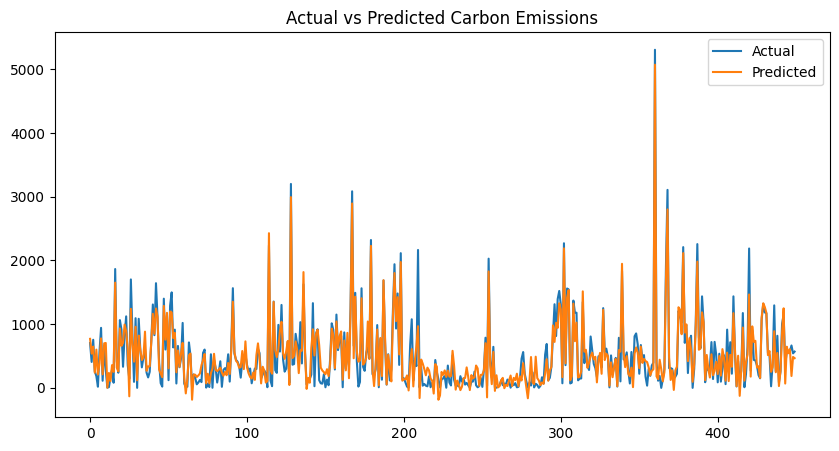

In [ ]:
predicted = lstm_model.predict(X)
predicted = scaler.inverse_transform(np.concatenate([np.zeros((len(predicted), len(features))), predicted], axis=1))[:, -1]

actual = flight_data[target].values[n_steps:]
plt.figure(figsize=(10,5))
plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Carbon Emissions")
plt.show()

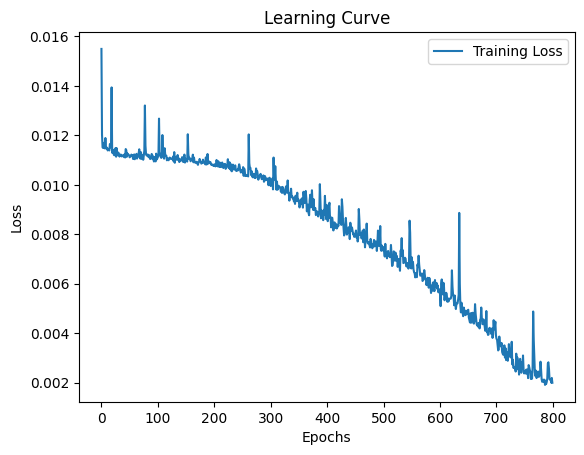

In [ ]:
plt.plot(lstmmodel.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error,r2_score
lstm_mape   = mean_absolute_percentage_error(actual, predicted)
lstm_r2   = r2_score(actual, predicted)

In [ ]:
print(lstm_mape,lstm_r2)

3908402051502741.5 0.8976251201665835


In [ ]:
from prophet import Prophet
import pandas as pd

prophet_df = flight_data[['callsign', 'emissions_kg']].rename(columns={'callsign': 'ds', 'emissions_kg': 'y'})

prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=30, freq='5min')  # Adjust based on time interval
forecast = prophet_model.predict(future)

prophet_model.plot(forecast)


/usr/local/lib/python3.11/dist-packages/holidays/deprecations/v1_incompatibility.py:40: FutureIncompatibilityWarning: 

This is a future version incompatibility warning from Holidays v0.69
to inform you about an upcoming change in our API versioning strategy that may affect your
project's dependencies. Starting from version 1.0 onwards, we will be following a loose form of
Semantic Versioning (SemVer, https://semver.org) to provide clearer communication regarding any
potential breaking changes.

This means that while we strive to maintain backward compatibility, there might be occasional
updates that introduce breaking changes to our API. To ensure the stability of your projects,
we highly recommend pinning the version of our API that you rely on. You can pin your current
holidays v0.x dependency (e.g., holidays==0.69) or limit it (e.g., holidays<1.0) in order to
avoid potentially unwanted upgrade to the version 1.0 when it's released (ETA 2025Q1-Q2).

If you have any questions or conc

DateParseError: Unknown datetime string format, unable to parse: AAL1150 , at position 1

In [ ]:
#GRU Model for Emissions Prediction
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input

def build_gru_model():
    model = Sequential([
        Input(shape=(X.shape[1], X.shape[2])),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(64),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

gru_model = build_gru_model()
gru_model.fit(X, y.reshape(-1, 1), epochs=1000, verbose=0)


In [ ]:
predictedg = gru_model.predict(X)
actualg = flight_data[target].values[n_steps:]

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [ ]:
gru_mape   = mean_absolute_percentage_error(actualg, predictedg)
gru_r2   = r2_score(actualg, predictedg)

In [ ]:
print(gru_mape,gru_r2)

713217161444.5504 -0.7721999083410027


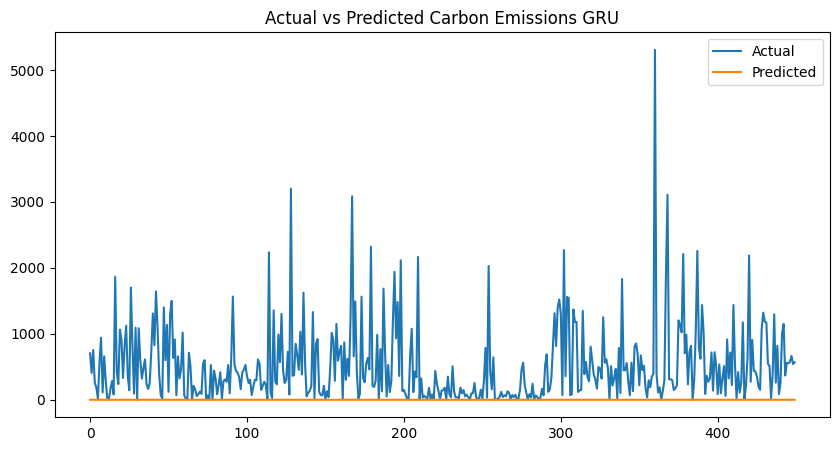

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(actualg, label="Actual")
plt.plot(predictedg, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Carbon Emissions GRU")
plt.show()

In [ ]:
print(predictedg.shape, actualg.shape)  # Check if they match
print(predictedg.min(), predictedg.max())  # Check range
print(actualg.min(), actualg.max())  # Compare with actual values


(456, 1) (456,)
-0.016510062 1.0265347
0.1251582070957944 3812.123205491137


In [ ]:
!pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 3.3 MB/s eta 0:00:00


In [ ]:
flight_data.columns

Index(['icao24', 'callsign', 'longitude', 'latitude', 'altitude', 'velocity',
       'nearest_airport_icao', 'nearest_airport_name', 'airport_lat',
       'airport_lon', 'distance_km', 'temperature', 'wind_speed', 'humidity',
       'burn_rate', 'fuel_burn_kg', 'emissions_kg', 'credits_needed',
       'credit_cost_usd'],
      dtype='object')

In [ ]:
from stable_baselines3 import PPO
from gym import spaces
import pandas as pd


flight_data = flight_data.sort_values(by="callsign")

features = ["credit_cost_usd", "emissions_kg", "fuel_burn_kg", "temperature", "wind_speed"]
scaler = MinMaxScaler()
flight_data[features] = scaler.fit_transform(flight_data[features])

# Create Sequences for LSTM
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])  # Predicting carbon_price
    return np.array(X), np.array(y)

X, y = create_sequences(flight_data[features].values)
X_train, X_test, y_train, y_test = X[:int(0.8*len(X))], X[int(0.8*len(X)):], y[:int(0.8*len(y))], y[int(0.8*len(y)):]

# Build LSTM Model
def build_lstm_model():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm_model()
lstm_model.fit(X_train, y_train, epochs=800, batch_size=16, verbose=1)

# Predict Future Prices
future_prices = lstm_model.predict(X_test)

Epoch 1/800


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0206
Epoch 2/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0161
Epoch 3/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0188
Epoch 4/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0188
Epoch 5/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0179
Epoch 6/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0146
Epoch 7/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0192
Epoch 8/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0219
Epoch 9/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0229
Epoch 10/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0175
Epoch 11/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0166
Epoch 12/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0191
Epoch 13/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0144
Epoch 14/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0163
Epoch 15/800
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0193
E

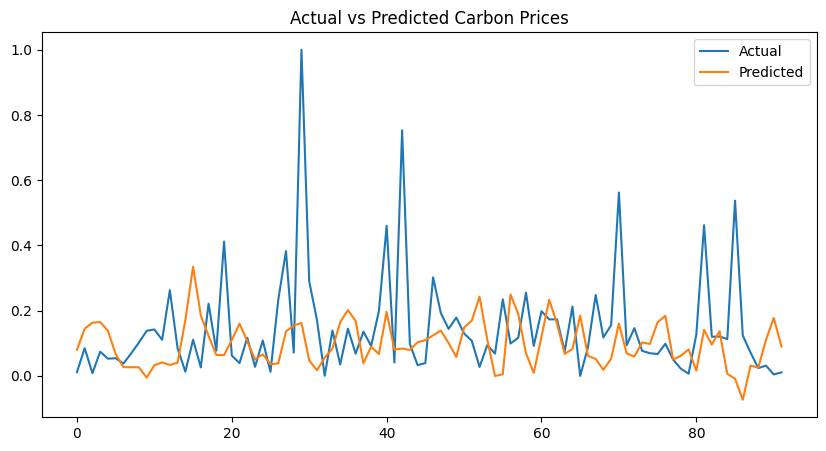

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual")
plt.plot(future_prices, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Carbon Prices")
plt.show()

In [ ]:
!pip install "shimmy>=2.0"

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

class CarbonCreditTradingEnv(gym.Env):
    def __init__(self, df):
        super(CarbonCreditTradingEnv, self).__init__()
        self.df = df
        self.current_step = 0
        self.action_space = gym.spaces.Discrete(3)  # Buy, Hold, Sell
        self.observation_space = gym.spaces.Box(low=0, high=np.inf, shape=(len(df.columns),), dtype=np.float32)
        self.balance = 10000  # Starting balance
        self.holdings = 0  # Carbon credits held

    def reset(self):
        self.current_step = 0
        self.balance = 10000
        self.holdings = 0
        self.initial_balance = self.balance  # Track initial balance
        return self.df.iloc[self.current_step].values

    def step(self, action):
        done = False
        current_data = self.df.iloc[self.current_step]

        # Define buy and sell price from dataset with dynamic market fluctuation
        buy_price = current_data['credit_cost_usd']
        sell_price = buy_price * (1 + np.random.uniform(-0.05, 0.05))  # 5% market fluctuation
        number_of_credits = 1  # Assuming one credit per transaction

        # Execute action
        if action == 0:  # Buy
            if self.balance >= buy_price:
                self.balance -= buy_price
                self.holdings += number_of_credits
        elif action == 1:  # Sell
            if self.holdings > 0:
                self.balance += sell_price
                self.holdings -= number_of_credits

        # Calculate reward: Profit from selling - cost of buying
        reward = (self.balance + self.holdings * sell_price) - (self.initial_balance + self.holdings * buy_price)

        self.current_step += 1
        if self.current_step >= len(self.df) - 1:
            done = True

        return self.df.iloc[self.current_step].values, reward, done, {}

# Load dataset (replace with actual dataset loading)
data = flight_data  # Your dataset
df = pd.DataFrame(data, columns=['credit_cost_usd', 'emissions_kg', 'credits_needed', 'fuel_burn_kg', 'temperature', 'wind_speed'])

# Create and wrap the environment
env = DummyVecEnv([lambda: CarbonCreditTradingEnv(df)])

# Train PPO Model
model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.001, ent_coef=0.01, n_steps=2048, batch_size=64, n_epochs=100)
model.learn(total_timesteps=10000)

# Simulate Trading
obs = env.reset()
for _ in range(100):
    action, _states = model.predict(obs)
    obs, rewards, done, _ = env.step(action)
    if done:
        break

print(f"Final Balance: {env.envs[0].balance}")



Using cpu device
-----------------------------
| time/              |      |
|    fps             | 773  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 173        |
|    iterations           | 2          |
|    time_elapsed         | 23         |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.01304836 |
|    clip_fraction        | 0.153      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.09      |
|    explained_variance   | 2.98e-07   |
|    learning_rate        | 0.001      |
|    loss                 | 4.38e+07   |
|    n_updates            | 100        |
|    policy_gradient_loss | -0.00874   |
|    value_loss           | 1.15e+08   |
----------------------------------------
-----------------------------------